In [ ]:
# ====================================================================================================
# HOME CREDIT DEFAULT RISK
# ====================================================================================================

# TAHAP 1: SETUP & IMPORT LIBRARIES
# ====================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score, confusion_matrix, 
                            classification_report, precision_score, recall_score, f1_score)

# Imbalanced Learning
from imblearn.over_sampling import SMOTE

# Gradient Boosting
import lightgbm as lgb
import xgboost as xgb


In [2]:
# ====================================================================================================
# TAHAP 2 & 3: LOAD DATA DAN EKSPLORASI AWAL
# ====================================================================================================

# Load main dataset
app_train = pd.read_csv('dataset/application_train.csv')
app_test = pd.read_csv('dataset/application_test.csv')
# bureau = pd.read_csv('dataset/bureau.csv')
# bureau_balance = pd.read_csv('dataset/bureau_balance.csv')
# previous_app = pd.read_csv('dataset/previous_application.csv')
# pos_cash = pd.read_csv('dataset/POS_CASH_balance.csv')
# credit_card = pd.read_csv('dataset/credit_card_balance.csv')
# installments = pd.read_csv('dataset/installments_payments.csv')

print(f"Training data shape: {app_train.shape}")
print(f"Test data shape: {app_test.shape}")
print(f"\\nTarget distribution:\\n{app_train['TARGET'].value_counts(normalize=True)}")

Training data shape: (307511, 122)
Test data shape: (48744, 121)
\nTarget distribution:\nTARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [3]:
# ====================================================================================================
# TAHAP 4: EKSPLORASI DATA AWAL (EDA)
# ====================================================================================================

# Analisis Missing Values
def analyze_missing(df):
    missing = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percent': (df.isnull().sum() / len(df)) * 100
    })
    missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
    return missing

missing_analysis = analyze_missing(app_train)
print(f"\\nColumns with missing values: {len(missing_analysis)}")

# Visualisasi Target Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=app_train, x='TARGET')
plt.title('Target Distribution (0: Repaid, 1: Default)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# Analisis Korelasi dengan Target
correlations = app_train.select_dtypes(include=['number']).corr()['TARGET'].sort_values(ascending=False)
print(f"\\nTop 10 Features Correlated with TARGET:\\n{correlations.head(10)}")

\nColumns with missing values: 67
\nTop 10 Features Correlated with TARGET:\nTARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64


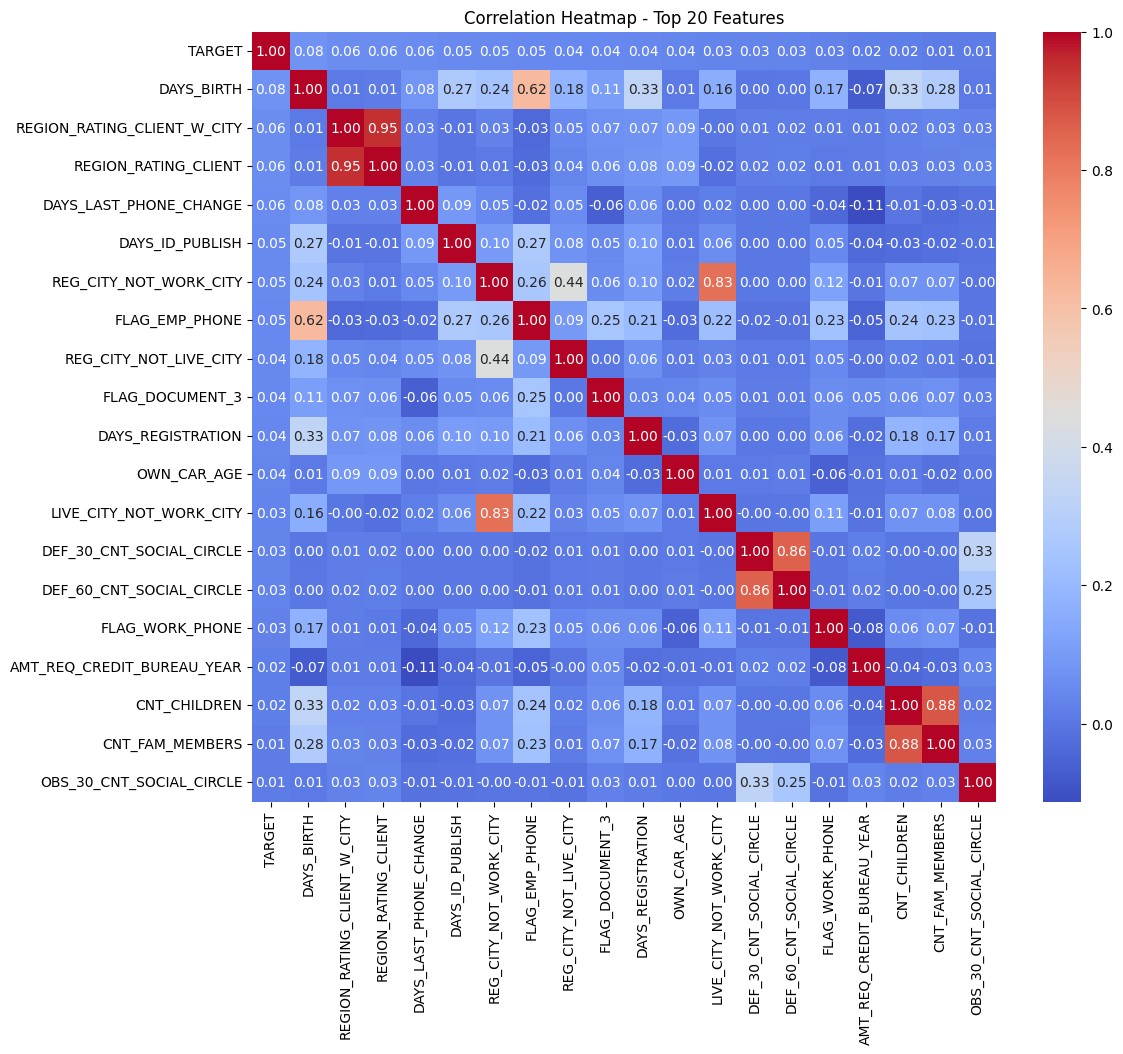

In [4]:
# Visualisasi Correlation Heatmap (Top Features)
top_features = correlations.head(20).index
plt.figure(figsize=(12, 10))
sns.heatmap(app_train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top 20 Features')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

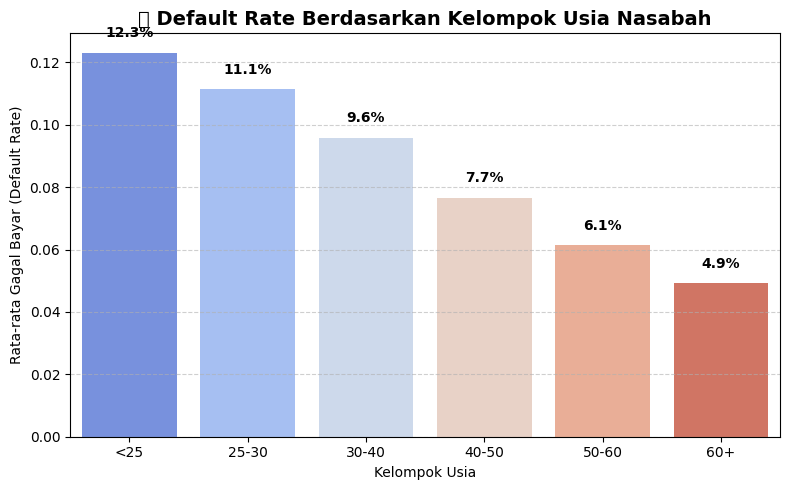

In [ ]:
# =====================================================================
# VISUALISASI INSIGHT #1: Risiko Gagal Bayar Berdasarkan Kelompok Usia
# =====================================================================

# Buat kolom usia dalam tahun
app_train['AGE_YEARS'] = (-app_train['DAYS_BIRTH']) / 365

# Kelompokkan usia menjadi kategori
bins = [18, 25, 30, 40, 50, 60, 70]
labels = ['<25', '25-30', '30-40', '40-50', '50-60', '60+']
app_train['AGE_GROUP'] = pd.cut(app_train['AGE_YEARS'], bins=bins, labels=labels, right=False)

# Hitung proporsi gagal bayar di setiap kelompok usia
age_risk = app_train.groupby('AGE_GROUP')['TARGET'].mean().reset_index()
age_risk.columns = ['Age Group', 'Default Rate']

# Visualisasikan dengan barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=age_risk, x='Age Group', y='Default Rate', palette='coolwarm')
plt.title('📊 Default Rate Berdasarkan Kelompok Usia Nasabah', fontsize=14, weight='bold')
plt.xlabel('Kelompok Usia')
plt.ylabel('Rata-rata Gagal Bayar (Default Rate)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tambahkan anotasi persentase di atas bar
for index, row in age_risk.iterrows():
    plt.text(index, row['Default Rate'] + 0.005, f"{row['Default Rate']*100:.1f}%", 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


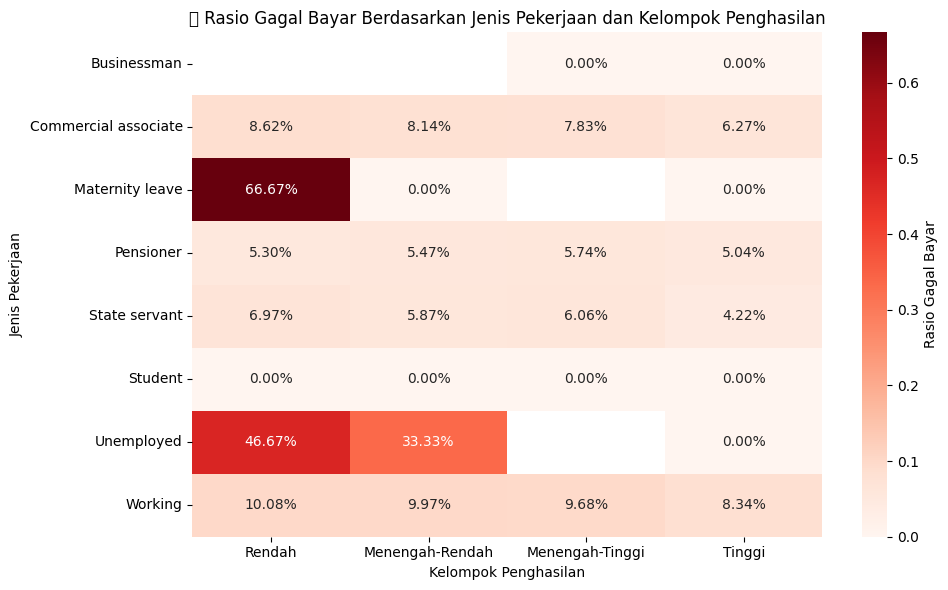

In [ ]:
# ================================================================
# INSIGHT #2: Penghasilan rendah & pekerjaan tidak tetap → risiko gagal bayar tinggi
# ================================================================

# Salin data
df_insight = app_train.copy()

# Pastikan kolom penting tersedia
cols_check = ['AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'TARGET']
assert all(col in df_insight.columns for col in cols_check), "Kolom yang dibutuhkan tidak lengkap!"

# Binning penghasilan agar mudah dibaca
df_insight['INCOME_GROUP'] = pd.qcut(
    df_insight['AMT_INCOME_TOTAL'], 
    q=4, 
    labels=['Rendah', 'Menengah-Rendah', 'Menengah-Tinggi', 'Tinggi']
)

# Hitung rasio gagal bayar per kategori pekerjaan dan kelompok penghasilan
fail_rate = (
    df_insight.groupby(['NAME_INCOME_TYPE', 'INCOME_GROUP'])['TARGET']
    .mean()
    .reset_index()
    .rename(columns={'TARGET': 'FAILURE_RATE'})
)

# Hitung distribusi kasus gagal bayar (jumlah)
fail_dist = (
    df_insight[df_insight['TARGET'] == 1]
    .groupby(['NAME_INCOME_TYPE', 'INCOME_GROUP'])
    .size()
    .reset_index(name='COUNT')
)

# Normalisasi ke persentase
fail_dist['PERCENT'] = 100 * fail_dist['COUNT'] / fail_dist['COUNT'].sum()

# ================================================================
# Visualisasi 1: Heatmap tingkat gagal bayar
# ================================================================
plt.figure(figsize=(10, 6))
pivot = fail_rate.pivot(index='NAME_INCOME_TYPE', columns='INCOME_GROUP', values='FAILURE_RATE')
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="Reds", cbar_kws={'label': 'Rasio Gagal Bayar'})
plt.title("💬 Rasio Gagal Bayar Berdasarkan Jenis Pekerjaan dan Kelompok Penghasilan")
plt.xlabel("Kelompok Penghasilan")
plt.ylabel("Jenis Pekerjaan")
plt.tight_layout()
plt.show()


In [7]:
# ====================================================================================================
# TAHAP 5: DATA CLEANING & PREPROCESSING
# ====================================================================================================

def preprocess_data(df, is_train=True):
    '''Preprocessing function for cleaning and encoding'''
    
    df = df.copy()
    
    # 1. Remove columns with >50% missing values
    missing_threshold = 0.5
    missing_cols = [col for col in df.columns 
                   if df[col].isnull().sum() / len(df) > missing_threshold]
    df = df.drop(columns=missing_cols)
    print(f"Removed {len(missing_cols)} columns with >{missing_threshold*100}% missing")
    
    # 2. Separate numeric and categorical columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    if is_train and 'TARGET' in numeric_cols:
        numeric_cols.remove('TARGET')
    if 'SK_ID_CURR' in numeric_cols:
        numeric_cols.remove('SK_ID_CURR')
    
    # 3. Impute missing values
    # Numeric: median imputation
    num_imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
    
    # Categorical: mode imputation
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
    
    # 4. Encode categorical variables
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
    
    # 5. Handle outliers (optional - using IQR method)
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        df[col] = df[col].clip(lower_bound, upper_bound)
    
    return df, le_dict

# Apply preprocessing
app_train_clean, label_encoders = preprocess_data(app_train, is_train=True)
print(f"\\nCleaned training data shape: {app_train_clean.shape}")

Removed 41 columns with >50.0% missing
\nCleaned training data shape: (307511, 83)


In [8]:
# ====================================================================================================
# TAHAP 6: FEATURE ENGINEERING
# ====================================================================================================

def feature_engineering(df):
    '''Create derived features'''
    
    df = df.copy()
    
    # 1. Income-related features
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_TERM'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
    
    # 2. Age-related features
    df['DAYS_EMPLOYED_PERCENT'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
    df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365
    
    # 3. Document flags
    doc_cols = [col for col in df.columns if 'FLAG_DOCUMENT' in col]
    df['TOTAL_DOCUMENTS'] = df[doc_cols].sum(axis=1)
    
    # 4. External sources combination
    if all(col in df.columns for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
        df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
        df['EXT_SOURCE_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
        df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    
    return df

# Apply feature engineering
app_train_fe = feature_engineering(app_train_clean)
print(f"\\nFeatures after engineering: {app_train_fe.shape[1]}")

\nFeatures after engineering: 90


In [ ]:
# ====================================================================================================
# TAHAP 7: HANDLING IMBALANCED DATA & MODEL PREPARATION
# ====================================================================================================

# Prepare features and target
X = app_train_fe.drop(['SK_ID_CURR', 'TARGET'], axis=1, errors='ignore')
y = app_train_fe['TARGET']

# ======================================
# Tangani missing values
# ======================================

# Pisahkan kolom numerik dan kategorikal
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(exclude=['number']).columns

# Isi NaN untuk masing-masing tipe
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# ======================================
# Encode fitur kategorikal
# ======================================

# Gunakan LabelEncoder untuk setiap kolom kategorikal
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# ======================================
# Split data
# ======================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Class distribution in training:\n{y_train.value_counts(normalize=True)}")

# ======================================
# SMOTE untuk menangani data imbalance
# ======================================
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Training set: {X_train_balanced.shape}")
print(f"Class distribution:\n{pd.Series(y_train_balanced).value_counts(normalize=True)}")

# ======================================
# Feature Scaling (khusus model linear/logreg)
# ======================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)



Training set: (246008, 88)
Validation set: (61503, 88)
Class distribution in training:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

After SMOTE:
Training set: (452296, 88)
Class distribution:
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


TRAINING MODEL 1: LOGISTIC REGRESSION
Logistic Regression AUC-ROC: 0.7327
Gini Coefficient: 0.4654
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     56538
           1       0.16      0.64      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.67      0.54     61503
weighted avg       0.89      0.70      0.77     61503



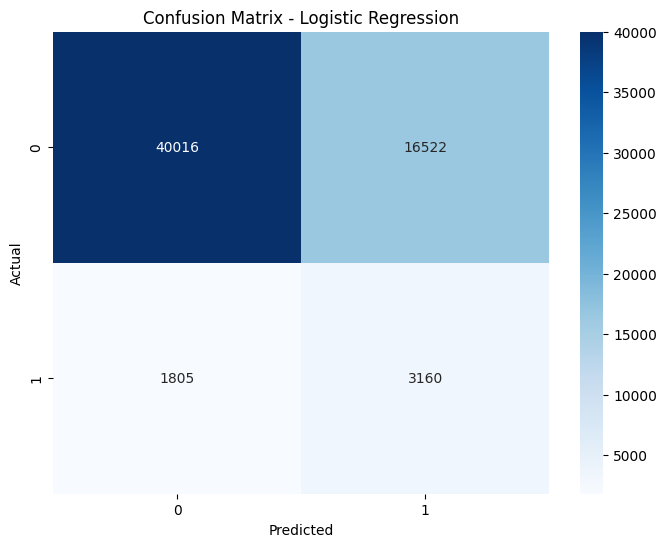

In [10]:
# ====================================================================================================
# TAHAP 8: MODEL 1 - LOGISTIC REGRESSION
# ====================================================================================================

print("" + "="*80)
print("TRAINING MODEL 1: LOGISTIC REGRESSION")
print("="*80)

# Train Logistic Regression
lr_model = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train_balanced)

# Predictions
y_pred_lr = lr_model.predict(X_val_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Evaluation
auc_lr = roc_auc_score(y_val, y_pred_proba_lr)
print(f"Logistic Regression AUC-ROC: {auc_lr:.4f}")
print(f"Gini Coefficient: {(2 * auc_lr - 1):.4f}")
print("Classification Report:")
print(classification_report(y_val, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_val, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('cm_logistic_regression.png', dpi=300, bbox_inches='tight')

TRAINING MODEL 2: LIGHTGBM
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.750298
[100]	valid_0's auc: 0.758469
[150]	valid_0's auc: 0.760721
[200]	valid_0's auc: 0.761753
[250]	valid_0's auc: 0.762286
[300]	valid_0's auc: 0.762259
[350]	valid_0's auc: 0.762458
[400]	valid_0's auc: 0.762494
Early stopping, best iteration is:
[373]	valid_0's auc: 0.762589
LightGBM AUC-ROC: 0.7626
Gini Coefficient: 0.5252
nClassification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503



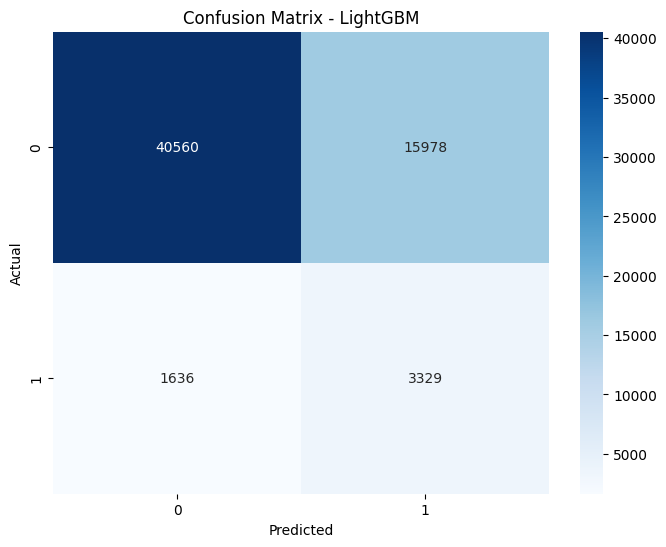

In [11]:
# ====================================================================================================
# TAHAP 9: MODEL 2 - LIGHTGBM
# ====================================================================================================

print("" + "="*80)
print("TRAINING MODEL 2: LIGHTGBM")
print("="*80)

# LightGBM parameters
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': 8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_estimators': 1000,
    'verbose': -1,
    'is_unbalance': True
}

# Train LightGBM
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,  # Use original imbalanced data with is_unbalance=True
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

# Predictions
y_pred_lgb = lgb_model.predict(X_val)
y_pred_proba_lgb = lgb_model.predict_proba(X_val)[:, 1]

# Evaluation
auc_lgb = roc_auc_score(y_val, y_pred_proba_lgb)
print(f"LightGBM AUC-ROC: {auc_lgb:.4f}")
print(f"Gini Coefficient: {(2 * auc_lgb - 1):.4f}")
print("nClassification Report:")
print(classification_report(y_val, y_pred_lgb))

# Confusion Matrix
cm_lgbm = confusion_matrix(y_val, y_pred_lgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('cm_lightgbm.png', dpi=300, bbox_inches='tight')

TRAINING MODEL 3: XGBOOST
[0]	validation_0-auc:0.68196
[50]	validation_0-auc:0.74989
[100]	validation_0-auc:0.75569
[150]	validation_0-auc:0.75678
[200]	validation_0-auc:0.75641
[250]	validation_0-auc:0.75584
[300]	validation_0-auc:0.75460
[350]	validation_0-auc:0.75396
[400]	validation_0-auc:0.75365
[450]	validation_0-auc:0.75265
[500]	validation_0-auc:0.75155
[550]	validation_0-auc:0.75096
[600]	validation_0-auc:0.75011
[650]	validation_0-auc:0.74854
[700]	validation_0-auc:0.74741
[750]	validation_0-auc:0.74640
[800]	validation_0-auc:0.74597
[850]	validation_0-auc:0.74494
[900]	validation_0-auc:0.74395
[950]	validation_0-auc:0.74311
[999]	validation_0-auc:0.74263
XGBoost AUC-ROC: 0.7426
Gini Coefficient: 0.4853
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91     56538
           1       0.23      0.41      0.30      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.65   

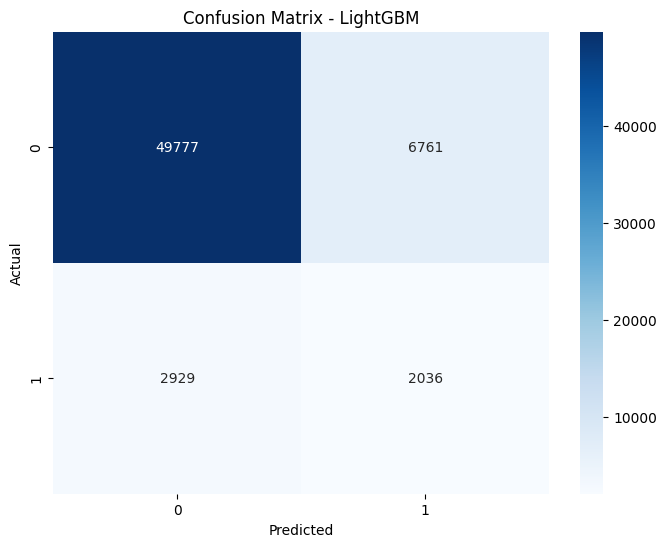

In [12]:
# ====================================================================================================
# TAHAP 10: MODEL 3 - XGBOOST
# ====================================================================================================

print("" + "="*80)
print("TRAINING MODEL 3: XGBOOST")
print("="*80)

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'max_depth': 8,
    'learning_rate': 0.05,
    'n_estimators': 1000,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Predictions
y_pred_xgb = xgb_model.predict(X_val)
y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Evaluation
auc_xgb = roc_auc_score(y_val, y_pred_proba_xgb)
print(f"XGBoost AUC-ROC: {auc_xgb:.4f}")
print(f"Gini Coefficient: {(2 * auc_xgb - 1):.4f}")
print("Classification Report:")
print(classification_report(y_val, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_val, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('cm_xgboost.png', dpi=300, bbox_inches='tight')

In [ ]:
# ====================================================================================================
# TAHAP 11: COMPARATIVE MODEL EVALUATION (dengan AKURASI, PRECISION, RECALL, dan F1)
# ====================================================================================================

print("="*80)
print("MODEL COMPARISON")
print("="*80)

# =======================================================================================
# ROC Curve Comparison
# =======================================================================================
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_pred_proba_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.4f})', linewidth=2)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# =======================================================================================
# Hitung Akurasi, Precision, Recall, F1-Score
# =======================================================================================
acc_lr = accuracy_score(y_val, y_pred_lr)
prec_lr = precision_score(y_val, y_pred_lr)
rec_lr = recall_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr)

acc_lgb = accuracy_score(y_val, y_pred_lgb)
prec_lgb = precision_score(y_val, y_pred_lgb)
rec_lgb = recall_score(y_val, y_pred_lgb)
f1_lgb = f1_score(y_val, y_pred_lgb)

acc_xgb = accuracy_score(y_val, y_pred_xgb)
prec_xgb = precision_score(y_val, y_pred_xgb)
rec_xgb = recall_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb)

# =======================================================================================
# Tabel Ringkasan Performa Model
# =======================================================================================
performance_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_lgb, auc_xgb],
    'Gini': [2*auc_lr - 1, 2*auc_lgb - 1, 2*auc_xgb - 1],
    'Accuracy': [acc_lr, acc_lgb, acc_xgb],
    'Precision': [prec_lr, prec_lgb, prec_xgb],
    'Recall': [rec_lr, rec_lgb, rec_xgb],
    'F1-Score': [f1_lr, f1_lgb, f1_xgb]
})

print("\n📊 Model Performance Summary:")
print(performance_summary.round(4).to_string(index=False))

# Simpan ke CSV
performance_summary.to_csv('model_performance_summary.csv', index=False)
print("\n✅ Hasil evaluasi disimpan ke 'model_performance_summary.csv'")


MODEL COMPARISON

📊 Model Performance Summary:
              Model  AUC-ROC   Gini  Accuracy  Precision  Recall  F1-Score
Logistic Regression   0.7327 0.4654    0.7020     0.1606  0.6365    0.2564
           LightGBM   0.7626 0.5252    0.7136     0.1724  0.6705    0.2743
            XGBoost   0.7426 0.4853    0.8424     0.2314  0.4101    0.2959

✅ Hasil evaluasi disimpan ke 'model_performance_summary.csv'


In [14]:
# ====================================================================================================
# FINAL INFERENCE DENGAN PIPELINE YANG SAMA (Logistic Regression, LightGBM, XGBoost, Best Model)
# + Pemilihan Threshold Terbaik Berdasarkan ROC Curve
# ====================================================================================================

# LOAD TEST DATA
app_test = pd.read_csv('dataset/application_test.csv')

# ====================================================================================================
# PREPROCESSING TEST (gunakan encoder & imputer hasil training)
# ====================================================================================================
def preprocess_test(df, le_dict, train_columns):
    df = df.copy()
    
    # Drop kolom dengan missing > 50% seperti di training
    missing_threshold = 0.5
    missing_cols = [col for col in df.columns if df[col].isnull().sum()/len(df) > missing_threshold]
    df = df.drop(columns=missing_cols, errors='ignore')
    
    # Pisahkan tipe data
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Imputasi nilai hilang
    num_imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
    
    # Gunakan encoder hasil training (LabelEncoder)
    for col, le in le_dict.items():
        if col in df.columns:
            df[col] = df[col].astype(str)
            df[col] = df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else 0)
    
    return df


# Preprocess + Feature Engineering
app_test_clean = preprocess_test(app_test, label_encoders, X.columns)
app_test_fe = feature_engineering(app_test_clean)

# Sesuaikan kolom dengan training
X_test = app_test_fe.reindex(columns=X.columns, fill_value=0)


# ====================================================================================================
# PILIH THRESHOLD TERBAIK DARI VALIDASI (gunakan Logistic Regression sebagai acuan)
# ====================================================================================================
print("="*90)
print("🔹 Menentukan Threshold Terbaik Berdasarkan ROC Curve (Youden’s J)")
print("="*90)

y_val_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
best_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"✅ Best Threshold (LogReg, Youden's J): {best_threshold:.4f}")
print(f"✅ AUC Logistic Regression Validation: {best_auc:.4f}")


# ====================================================================================================
# LOGISTIC REGRESSION (dengan SCALER)
# ====================================================================================================
print("\n" + "="*90)
print("🔹 Logistic Regression Inference")
print("="*90)

X_test_scaled = scaler.transform(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_label_lr = (y_pred_proba_lr >= best_threshold).astype(int)

submission_lr = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET_PROBA': y_pred_proba_lr,
    'TARGET_LABEL': y_pred_label_lr
})
submission_lr.to_csv('submission_inference_logreg.csv', index=False)
print("✅ Logistic Regression inference selesai → submission_inference_logreg.csv")
display(submission_lr.head(10))


# ====================================================================================================
# LIGHTGBM (tanpa scaling)
# ====================================================================================================
print("\n" + "="*90)
print("🔹 LightGBM Inference")
print("="*90)

y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_label_lgb = (y_pred_proba_lgb >= best_threshold).astype(int)

submission_lgb = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET_PROBA': y_pred_proba_lgb,
    'TARGET_LABEL': y_pred_label_lgb
})
submission_lgb.to_csv('submission_inference_lightgbm.csv', index=False)
print("✅ LightGBM inference selesai → submission_inference_lightgbm.csv")
display(submission_lgb.head(10))


# ====================================================================================================
# XGBOOST (tanpa scaling)
# ====================================================================================================
print("\n" + "="*90)
print("🔹 XGBoost Inference")
print("="*90)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_label_xgb = (y_pred_proba_xgb >= best_threshold).astype(int)

submission_xgb = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET_PROBA': y_pred_proba_xgb,
    'TARGET_LABEL': y_pred_label_xgb
})
submission_xgb.to_csv('submission_inference_xgboost.csv', index=False)
print("✅ XGBoost inference selesai → submission_inference_xgboost.csv")
display(submission_xgb.head(10))

# ====================================================================================================
# 📊 Ringkasan Distribusi Probabilitas Semua Model
# ====================================================================================================
def summary_proba(name, y_pred):
    q = np.percentile(y_pred, [0, 1, 5, 25, 50, 75, 90, 99, 100])
    print(f"\n📈 {name} Percentiles:", np.round(q, 6))
    print(f"{name} min/max/mean:", y_pred.min(), y_pred.max(), y_pred.mean())

summary_proba("LogReg", y_pred_proba_lr)
summary_proba("LightGBM", y_pred_proba_lgb)
summary_proba("XGBoost", y_pred_proba_xgb)


🔹 Menentukan Threshold Terbaik Berdasarkan ROC Curve (Youden’s J)
✅ Best Threshold (LogReg, Youden's J): 0.4508
✅ AUC Logistic Regression Validation: 0.7327

🔹 Logistic Regression Inference
✅ Logistic Regression inference selesai → submission_inference_logreg.csv


,SK_ID_CURR,TARGET_PROBA,TARGET_LABEL
0,100001,0.791894,1
1,100005,0.883269,1
2,100013,0.387462,0
3,100028,0.088098,0
4,100038,0.652840,1
5,100042,0.301205,0
6,100057,0.469168,1
7,100065,0.696326,1
8,100066,0.281427,0
9,100067,0.489814,1



🔹 LightGBM Inference
✅ LightGBM inference selesai → submission_inference_lightgbm.csv


,SK_ID_CURR,TARGET_PROBA,TARGET_LABEL
0,100001,0.339121,0
1,100005,0.710578,1
2,100013,0.128425,0
3,100028,0.386949,0
4,100038,0.616525,1
5,100042,0.323854,0
6,100057,0.243169,0
7,100065,0.461971,1
8,100066,0.165667,0
9,100067,0.465071,1



🔹 XGBoost Inference
✅ XGBoost inference selesai → submission_inference_xgboost.csv


,SK_ID_CURR,TARGET_PROBA,TARGET_LABEL
0,100001,0.118158,0
1,100005,0.495616,1
2,100013,0.052365,0
3,100028,0.235179,0
4,100038,0.332518,0
5,100042,0.099600,0
6,100057,0.072973,0
7,100065,0.302442,0
8,100066,0.038721,0
9,100067,0.129212,0



📈 LogReg Percentiles: [0.       0.07841  0.19209  0.443844 0.660463 0.878633 0.999913 1.
 1.      ]
LogReg min/max/mean: 6.000553329208142e-51 1.0 0.6471332669111977

📈 LightGBM Percentiles: [0.010934 0.042473 0.081075 0.202934 0.356616 0.549711 0.693645 0.838814
 0.928525]
LightGBM min/max/mean: 0.010934195385963682 0.9285249320360605 0.38252757647343644

📈 XGBoost Percentiles: [1.10000e-05 1.40000e-03 6.48100e-03 4.43340e-02 1.37040e-01 3.14760e-01
 5.16082e-01 7.75220e-01 9.57422e-01]
XGBoost min/max/mean: 1.08566255e-05 0.9574222 0.20501111
